# Automated Traffic Pattern Analysis Using AI.

# Problem Statement : Urban cities experience increasing traffic congestion due to rapid population growth, rising vehicle density, inefficient traffic light cycles, and unoptimized road usage. Traditional traffic monitoring systems rely on manual observation or fixed-timer signals, which often fail to adapt to real-time traffic conditions. This leads to:

# Longer travel times
# Increased fuel consumption
# Higher emissions
# Frequent traffic bottlenecks
# Poor traffic flow at major junctions
# There is a strong need for a data-driven and AI-powered solution that can analyze traffic patterns, detect congestion hotspots, and recommend optimal traffic flow improvements.

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from datetime import datetime, timedelta
import random

In [12]:
df = pd.read_csv(r"C:\Users\Prakhar Khandelwal\Downloads\Traffic_dataset.csv")
df.head()

,Time,Date,Dayoftheweek,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation
0,00:00,10,Tuesday,31,0,4,4,39,Low
1,00:15,10,Tuesday,49,0,3,3,55,Low
2,00:30,10,Tuesday,46,0,3,6,55,Low
3,00:45,10,Tuesday,51,0,2,5,58,Low
4,01:00,10,Tuesday,57,6,15,16,94,Normal


In [14]:
df_clean=df

In [5]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2976 entries, 0 to 2975
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Time               2976 non-null   object
 1   Date               2976 non-null   int64 
 2   Day of the week    2976 non-null   object
 3   CarCount           2976 non-null   int64 
 4   BikeCount          2976 non-null   int64 
 5   BusCount           2976 non-null   int64 
 6   TruckCount         2976 non-null   int64 
 7   Total              2976 non-null   int64 
 8   Traffic Situation  2976 non-null   object
dtypes: int64(6), object(3)
memory usage: 209.4+ KB


In [6]:
# Check missing values
print(df_clean.isnull().sum())

Time                 0
Date                 0
Day of the week      0
CarCount             0
BikeCount            0
BusCount             0
TruckCount           0
Total                0
Traffic Situation    0
dtype: int64


In [7]:
# Exploratory Data Analysis
print(df_clean.describe())
print(df_clean['Traffic Situation'].value_counts())

              Date     CarCount    BikeCount     BusCount   TruckCount  \
count  2976.000000  2976.000000  2976.000000  2976.000000  2976.000000   
mean     16.000000    68.696573    14.917339    15.279570    15.324933   
std       8.945775    45.850693    12.847518    14.341986    10.603833   
min       1.000000     6.000000     0.000000     0.000000     0.000000   
25%       8.000000    19.000000     5.000000     1.000000     6.000000   
50%      16.000000    64.000000    12.000000    12.000000    14.000000   
75%      24.000000   107.000000    22.000000    25.000000    23.000000   
max      31.000000   180.000000    70.000000    50.000000    40.000000   

             Total  
count  2976.000000  
mean    114.218414  
std      60.190627  
min      21.000000  
25%      55.000000  
50%     109.000000  
75%     164.000000  
max     279.000000  
Traffic Situation
normal    1669
heavy      682
high       321
low        304
Name: count, dtype: int64


In [8]:
# Formatting Date Column
start_date = datetime(2023, 1, 10)   # starting date
df_clean['Date'] = [(start_date + timedelta(days=i // 96)).date() for i in range(len(df))] # For every 96 rows, the day should increase by +1 

In [15]:
# Generate Synthetic Columns aligned with AI Analysis
# 1. WeatherCondition: random values from a fixed list
n=4992
weather_list = ["Sunny", "Cloudy", "Rainy", "Foggy", "Windy"]
df["WeatherCondition"] = np.random.choice(weather_list, size=n)
df["JunctionID"] = np.random.randint(1, 5, size=n)
df["AverageSpeed"] = np.random.uniform(20, 80, size=n).round(2)
df_clean['VehicleDensity'] = df_clean['Total'] / 100  # Example density metric
df_clean['CongestionLevel'] = df_clean['Total'].apply(lambda x: 'High' if x>70 else ('Medium' if x>40 else 'Low'))
df_clean['PeakHour'] = df_clean['Time'].str[:2].astype(int).apply(
    lambda x: 1 if (7 <= x <= 10 or 17 <= x <= 20) else 0
)

In [16]:
df_clean.head()

,Time,Date,Dayoftheweek,CarCount,BikeCount,BusCount,TruckCount,Total,Traffic Situation,WeatherCondition,JunctionID,AverageSpeed,VehicleDensity,CongestionLevel,PeakHour
0,00:00,10,Tuesday,31,0,4,4,39,Low,Rainy,4,23.18,0.39,Low,0
1,00:15,10,Tuesday,49,0,3,3,55,Low,Rainy,4,37.23,0.55,Medium,0
2,00:30,10,Tuesday,46,0,3,6,55,Low,Sunny,1,55.52,0.55,Medium,0
3,00:45,10,Tuesday,51,0,2,5,58,Low,Rainy,3,56.13,0.58,Medium,0
4,01:00,10,Tuesday,57,6,15,16,94,Normal,Cloudy,1,52.19,0.94,High,0


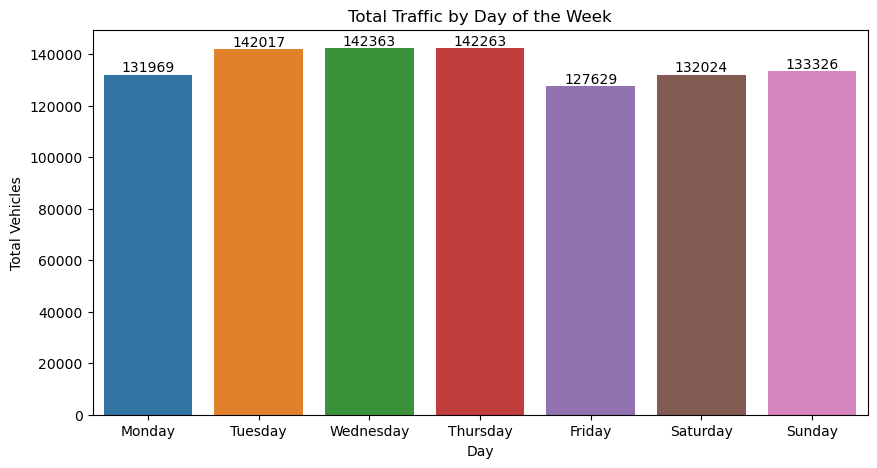

In [17]:
# Simple Bar Chart: Total Traffic by Day of Week
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

traffic_by_day = df_clean.groupby('Dayoftheweek')['Total'].sum().reindex(order)

plt.figure(figsize=(10,5))
sns.barplot(x=traffic_by_day.index, y=traffic_by_day.values)

# Add labels
for i, v in enumerate(traffic_by_day.values):
    plt.text(i, v, int(v), ha='center', va='bottom')

plt.title('Total Traffic by Day of the Week')
plt.xlabel('Day')
plt.ylabel('Total Vehicles')
plt.show()

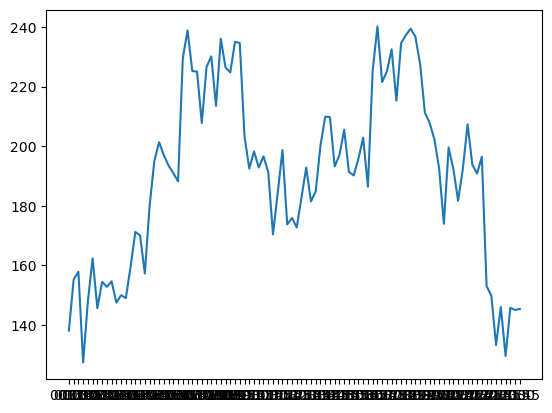

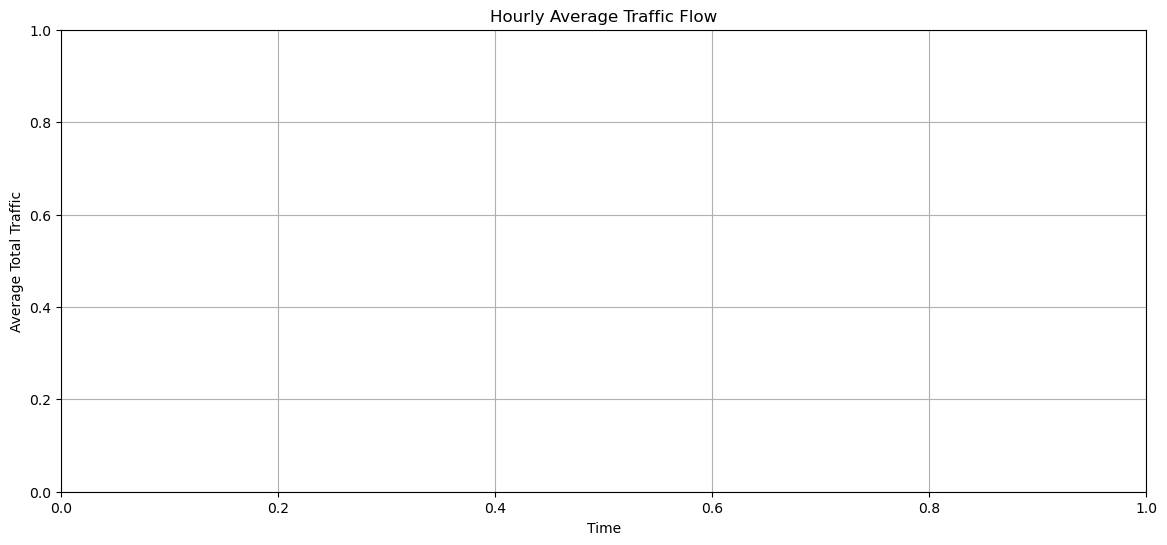

In [18]:
# Group by hour and calculate mean Total
hourly_mean = df.groupby('Time')['Total'].mean()

plt.plot(hourly_mean.index, hourly_mean.values)
plt.figure(figsize=(14,6))
plt.xlabel('Time')
plt.ylabel('Average Total Traffic')
plt.title('Hourly Average Traffic Flow')
plt.grid(True)
plt.show()

<Axes: ylabel='count'>

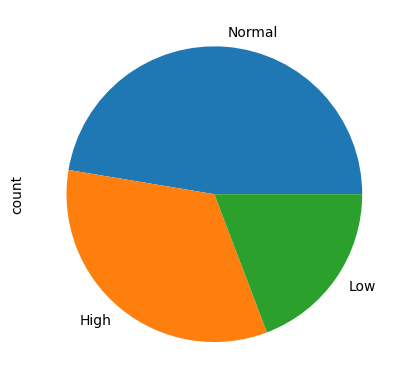

In [19]:
df_clean['Traffic Situation'].value_counts().plot(kind='pie')

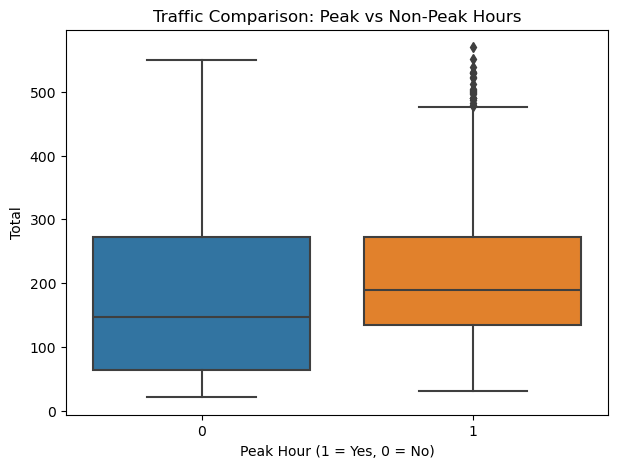

In [20]:
plt.figure(figsize=(7,5))
sns.boxplot(x='PeakHour', y='Total', data=df)
plt.title("Traffic Comparison: Peak vs Non-Peak Hours")
plt.xlabel("Peak Hour (1 = Yes, 0 = No)")
plt.show()

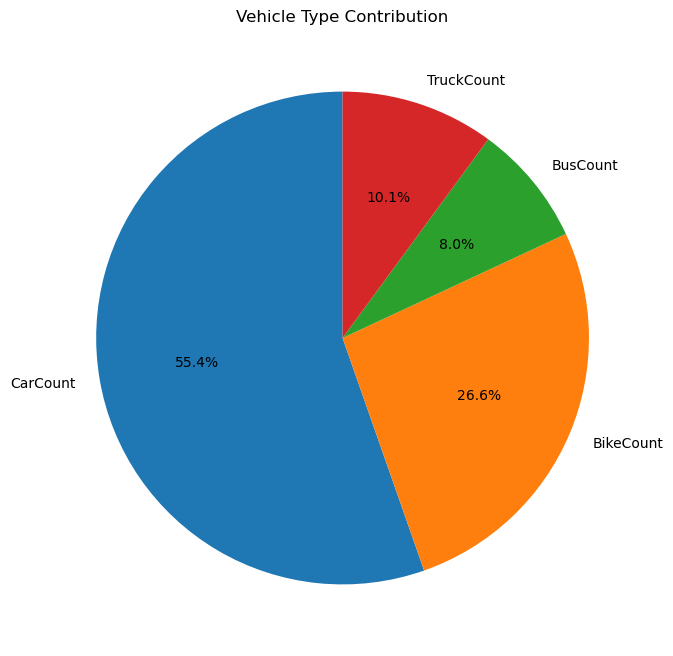

In [21]:
vehicle_cols = ['CarCount', 'BikeCount', 'BusCount', 'TruckCount']

plt.figure(figsize=(8,8))
df[vehicle_cols].sum().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title("Vehicle Type Contribution")
plt.ylabel("")   # Removes default y-label
plt.show()

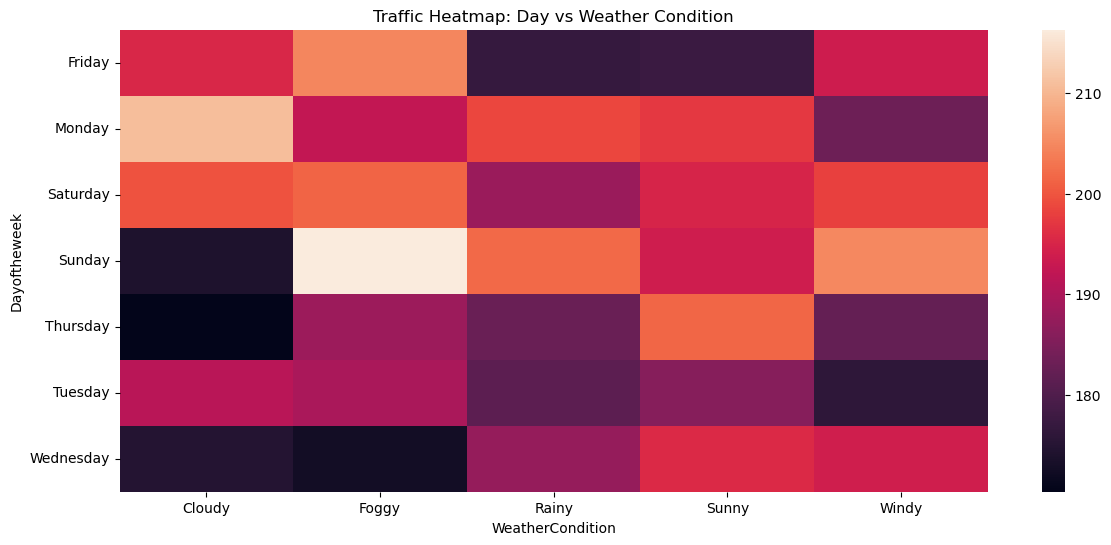

In [24]:
pivot = df_clean.pivot_table(values='Total', index='Dayoftheweek', columns='WeatherCondition', aggfunc='mean')

plt.figure(figsize=(14,6))
sns.heatmap(pivot, annot=False)
plt.title("Traffic Heatmap: Day vs Weather Condition")
plt.show()

# Step 2: Detect Congestion Points Using AI (Clustering)


In [25]:
features = ['CarCount','BikeCount','BusCount','TruckCount','AverageSpeed','PeakHour']
X = df_clean[features]

In [26]:
# Normalize data
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [27]:
# KMeans Clustering to detect congestion patterns
kmeans = KMeans(n_clusters=3, random_state=42)
df['CongestionCluster'] = kmeans.fit_predict(X_scaled)

# Map clusters to congestion labels
cluster_mapping = {0:'Low',1:'Medium',2:'High'}
df['CongestionClusterLabel'] = df['CongestionCluster'].map(cluster_mapping)

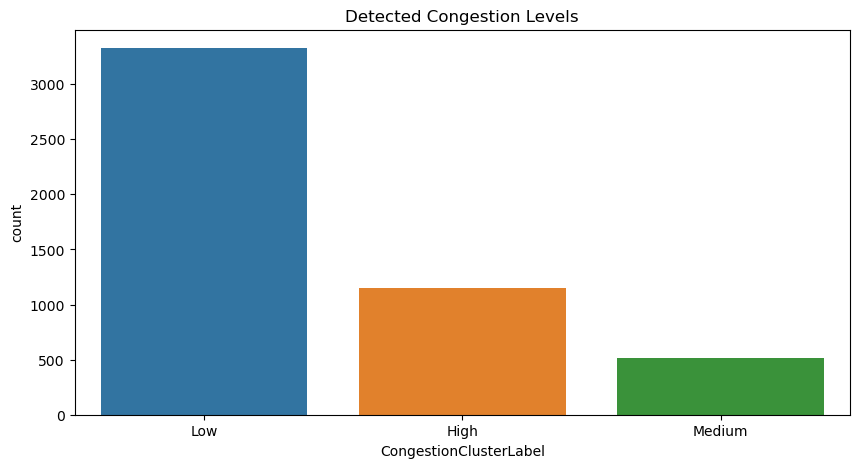

In [28]:
# Visualize congestion clusters
plt.figure(figsize=(10,5))
sns.countplot(x='CongestionClusterLabel', data=df)
plt.title('Detected Congestion Levels')
plt.show()

# Step 3: Predict Traffic Using Linear Regression

In [29]:
# Encode categorical columns
le = LabelEncoder()
df['WeatherCondition'] = le.fit_transform(df['WeatherCondition'])
df['Dayoftheweek'] = le.fit_transform(df['Dayoftheweek'])

In [30]:
# Target: Total traffic
X = df_clean[['CarCount','BikeCount','BusCount','TruckCount','WeatherCondition','Dayoftheweek','PeakHour']]
y = df_clean['Total']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
# Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))

MSE: 1.705190361757736e-27


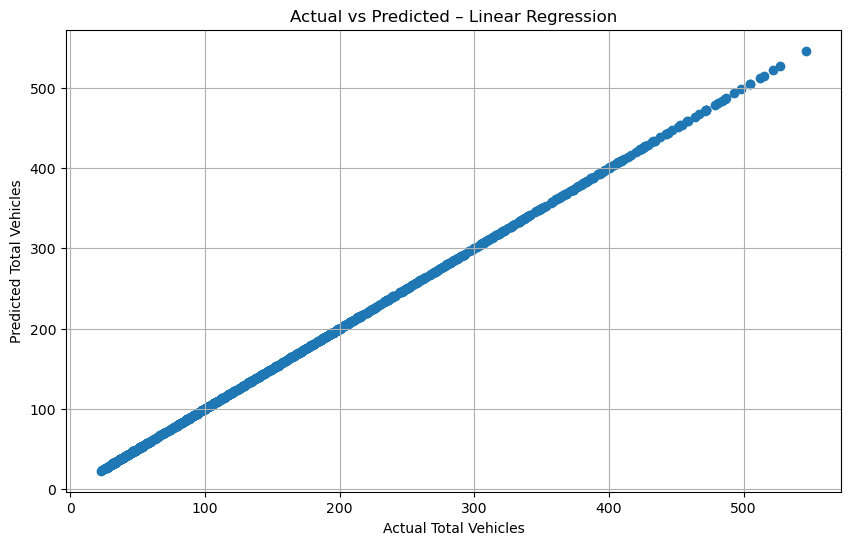

In [32]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Total Vehicles")
plt.ylabel("Predicted Total Vehicles")
plt.title("Actual vs Predicted – Linear Regression")
plt.grid(True)
plt.show()

# Step 4: Generate Recommendations

In [35]:
def recommend(row):
    if row['CongestionClusterLabel']=='High':
        return "Reroute traffic / Increase green light duration"
    elif row['CongestionClusterLabel']=='Medium':
        return "Monitor closely / Adjust signals"
    else:
        return "No action needed"

df_clean['Recommendation'] = df_clean.apply(recommend, axis=1)
print(df_clean[['JunctionID','Time','Total','CongestionClusterLabel','Recommendation']].head(30))

    JunctionID   Time  Total CongestionClusterLabel  \
0            4  00:00     39                    Low   
1            4  00:15     55                    Low   
2            1  00:30     55                    Low   
3            3  00:45     58                    Low   
4            1  01:00     94                    Low   
5            3  01:15     53                    Low   
6            3  01:30     42                    Low   
7            4  01:45     55                    Low   
8            3  02:00     67                    Low   
9            4  02:15     45                    Low   
10           4  02:30     47                    Low   
11           2  02:45     49                    Low   
12           2  03:00     53                    Low   
13           1  03:15     42                    Low   
14           2  03:30    194                    Low   
15           2  03:45    209                    Low   
16           3  04:00    162                    Low   
17        

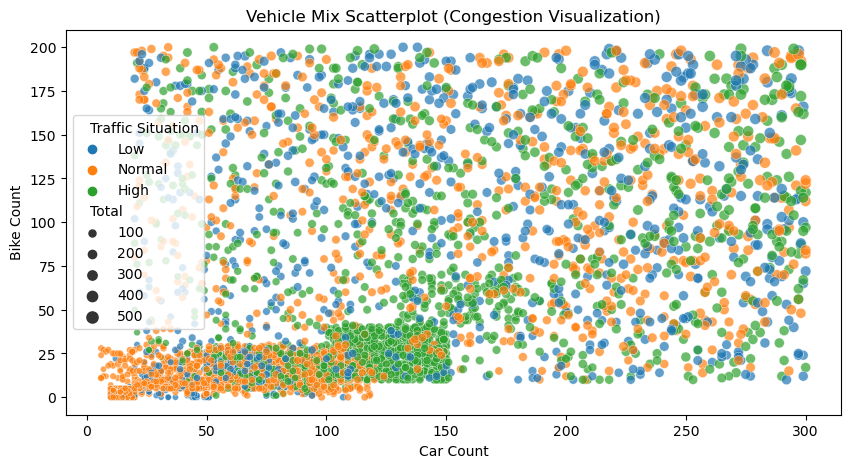

In [36]:
plt.figure(figsize=(10,5))
sns.scatterplot(
    x='CarCount',
    y='BikeCount',
    hue='Traffic Situation',
    size='Total',
    alpha=0.7,
    data=df
)

plt.title("Vehicle Mix Scatterplot (Congestion Visualization)")
plt.xlabel("Car Count")
plt.ylabel("Bike Count")
plt.show()